# NLP Assignment - BA Text Mining | VU Amsterdam

## Three NLP tasks on 10 review sentences

| Section | Task | System(s) | Note |
|---------|------|-----------|------|
| 1 | NERC | **System A: spaCy** vs **System B: NLTK MaxEnt** | Two-system deep-dive |
| 2 | Sentiment | **System A: VADER** vs **System B: TextBlob** | Two-system deep-dive |
| 3 | Topic | SVM + TF-IDF | one system |

**Two-system comparisons -> Sections 1 (NERC) and 2 (Sentiment).** All tasks run at the required level: NERC at token level, Sentiment and Topic at sentence level.

> Run all cells top-to-bottom. All data and models load automatically.

## Setup
Run once to install packages and download models.

In [1]:
import subprocess, sys
for pkg in ["spacy","vaderSentiment","textblob","scikit-learn","pandas","numpy","nltk","matplotlib","seaborn"]:
    subprocess.run([sys.executable,"-m","pip","install",pkg,"-q"], check=True)
subprocess.run([sys.executable,"-m","spacy","download","en_core_web_sm","--quiet"], check=True)

import nltk
for r in ["movie_reviews","stopwords","punkt","punkt_tab","subjectivity",
          "gutenberg","brown","averaged_perceptron_tagger_eng","maxent_ne_chunker","words"]:
    nltk.download(r, quiet=True)
print("Setup complete")

Setup complete


In [2]:
import pandas as pd, numpy as np, warnings, random, urllib.request, io
from pathlib import Path
import spacy
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, accuracy_score,
                             confusion_matrix, f1_score)
from nltk import ne_chunk, pos_tag, word_tokenize
from nltk.tree import Tree
from nltk.corpus import movie_reviews, subjectivity, gutenberg, brown
from nltk.tokenize import sent_tokenize
from collections import Counter
import matplotlib.pyplot as plt, seaborn as sns

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)
print("Imports OK")

Imports OK


## Load Test Data

Place `NER-test.tsv` and `Sentiment-topic-test.tsv` in the same folder as this notebook.

In [3]:
NER_PATH  = Path("NER-test.tsv")
SENT_PATH = Path("Sentiment-topic-test.tsv")

def load_ner(path):
    df = pd.read_csv(path, sep="\t")
    sents = {}
    for _, r in df.iterrows():
        sid = int(r["sentence id"])
        if sid not in sents:
            sents[sid] = {"tokens": [], "gold_tags": []}
        sents[sid]["tokens"].append(str(r["token"]))
        sents[sid]["gold_tags"].append(str(r["BIO NER tag"]))
    return sents

sent_df   = pd.read_csv(SENT_PATH, sep="\t")
ner_sents = load_ner(NER_PATH)
TEXTS      = sent_df["text"].tolist()
GOLD_SENT  = sent_df["sentiment"].tolist()
GOLD_TOPIC = sent_df["topic"].tolist()

print(f"Test sentences: {len(sent_df)}")
print(f"Sentiment distribution: {dict(pd.Series(GOLD_SENT).value_counts())}")
print(f"Topic distribution:     {dict(pd.Series(GOLD_TOPIC).value_counts())}")
sent_df[["sentence id","text","sentiment","topic"]]

Test sentences: 10
Sentiment distribution: {'positive': 4, 'negative': 3, 'neutral': 3}
Topic distribution:     {'movie': 5, 'restaurant': 3, 'book': 2}


,sentence id,text,sentiment,topic
0,0,It took eight years for Warner Brothers to rec...,negative,movie
1,1,All the New York University students love this...,positive,restaurant
2,2,This Italian place is really trendy but they h...,negative,restaurant
3,3,"In conclusion, my review of this book would be...",positive,book
4,4,The story of this movie is focused on Carl Bra...,neutral,movie
5,5,Chris O'Donnell stated that while filming for ...,neutral,movie
6,6,My husband and I moved to Amsterdam 6 years ag...,positive,restaurant
7,7,Dame Maggie Smith performed her role excellent...,positive,movie
8,8,The new movie by Mr. Kruno was shot in New Yor...,neutral,movie
9,9,"I always have loved English novels, but I just...",negative,book


## Dataset Description

**Test data (provided).**
- `NER-test.tsv`: 214 token rows (215 lines incl. header) across 10 sentences; 4 columns (sentence id, token id, token, BIO NER tag). Entities are PER, ORG, LOC and MISC in BIO format.
- `Sentiment-topic-test.tsv`: 10 sentences; 4 columns (sentence id, text, sentiment, topic). Sentiment in {positive, neutral, negative}; topic in {movie, restaurant, book}.

**Training data (supervised topic classifier only).**
- NLTK `movie_reviews` (Pang and Lee 2004): 2,000 review documents, split into sentences for the *movie* class.
- NLTK `gutenberg`: 8 literary works (Austen, Melville, Carroll, Chesterton, Shakespeare, Edgeworth), split into sentences for the *book* class.
- NLTK `brown` (reviews + food-filtered hobbies categories) for the *restaurant* class.

**Rule-based / pre-trained systems (no training data collected by us).**
- NERC: spaCy `en_core_web_sm` (OntoNotes 5) and NLTK MaxEnt chunker (ACE 2004).
- Sentiment: VADER lexicon (Hutto and Gilbert 2014) and TextBlob / Pattern lexicon.

**Test-set label distribution.** Sentiment = {positive: 4, neutral: 3, negative: 3}; topic = {movie: 5, restaurant: 3, book: 2}; the 10 NER sentences contain PER / ORG / LOC / MISC entity tokens.

---
# Section 1 - Named Entity Recognition & Classification (NERC)

## Task
Identify named entity spans and assign BIO tags at the **token level**:

| Tag | Type | Examples in test set |
|-----|------|----------------------|
| B-/I-PER | Person | Jane Austen, Cuba Gooding Jr., Dame Maggie Smith, Mr. Kruno |
| B-/I-ORG | Organisation | Warner Brothers, New York University, the Navy, Blauwbrug |
| B-/I-LOC | Location | Amsterdam, Soho, New York, Los Angeles |
| B-/I-MISC | Miscellaneous | Italian, African American, English |
| O | Outside | all other tokens |

**B-** = beginning of entity span - **I-** = inside/continuation - **O** = outside

## Two Systems Compared

### System A: spaCy `en_core_web_sm` (CNN-based neural NER)
A modern neural NER model trained on **OntoNotes 5** (~1M words: news, web, broadcast). Uses a CNN token encoder with a transition-based NER decoder. spaCy's label taxonomy is mapped to CoNLL BIO: `PERSON -> PER`, `ORG -> ORG`, `GPE -> LOC`, `NORP -> MISC`, others  ->  `MISC`

### System B: NLTK MaxEnt NE Chunker (Maximum Entropy NER)
A classical Maximum Entropy (log-linear) model trained on **ACE 2004**, built into NLTK. Two-step pipeline: averaged perceptron POS tagger  ->  MaxEnt NE chunker. NLTK labels: `PERSON`, `ORGANIZATION`, `GPE`, `LOCATION`, `FACILITY`, `GSP`.

### Why compare these two systems?

| | System A: spaCy CNN | System B: NLTK MaxEnt |
|--|--|--|
| **Architecture** | Neural CNN encoder | Maximum Entropy log-linear |
| **Feature learning** | Automatic (embeddings) | Manual (hand-crafted) |
| **Training data** | OntoNotes 5 (~1M tokens) | ACE 2004 corpus |
| **Context window** | Full sentence (CNN) | Local +/-2 token window |
| **Era** | Modern deep learning | Classical ML |

These systems fail in **systematically different ways** - that contrast is what makes the error analysis rich and the comparison academically valuable.


In [4]:
# -- Label mappings --
SPACY_TO_CONLL = {
    "PERSON":"PER","ORG":"ORG","GPE":"LOC","LOC":"LOC",
    "NORP":"MISC","FAC":"MISC","PRODUCT":"MISC",
    "EVENT":"MISC","WORK_OF_ART":"MISC","LANGUAGE":"MISC",
}
NLTK_TO_CONLL = {
    "PERSON":"PER","ORGANIZATION":"ORG",
    "GPE":"LOC","LOCATION":"LOC","FACILITY":"ORG","GSP":"LOC",
}

# -- Load System A: spaCy --
nlp = spacy.load("en_core_web_sm")
print(f"System A - spaCy: {nlp.meta['name']} | OntoNotes 5")

# -- Verify System B: NLTK MaxEnt --
_test = ne_chunk(pos_tag(word_tokenize("Jane Austen is a British author.")), binary=False)
_ents = [(c.label(), " ".join(w for w,_ in c.leaves())) for c in _test if isinstance(c, Tree)]
print(f"System B - NLTK MaxEnt NE Chunker | ACE 2004")
print(f"   Quick test: {_ents}")

System A - spaCy: core_web_sm | OntoNotes 5


System B - NLTK MaxEnt NE Chunker | ACE 2004
   Quick test: [('PERSON', 'Jane'), ('ORGANIZATION', 'Austen'), ('GPE', 'British')]


In [5]:
def run_spacy_ner(nlp, sents):
    """Run spaCy and align predictions to original tokens via char offsets."""
    preds = {}
    for sid, data in sents.items():
        tokens = data["tokens"]
        text   = " ".join(tokens)
        doc    = nlp(text)
        char_label = {}
        for ent in doc.ents:
            mapped = SPACY_TO_CONLL.get(ent.label_)
            if not mapped: continue
            for i, ch in enumerate(range(ent.start_char, ent.end_char)):
                char_label[ch] = f"{'B' if i==0 else 'I'}-{mapped}"
        pred_tags, pos = [], 0
        for tok in tokens:
            pred_tags.append(char_label.get(pos, "O"))
            pos += len(tok) + 1
        preds[sid] = pred_tags
    return preds

def run_nltk_ner(sents):
    """Run NLTK MaxEnt chunker and convert Tree output to BIO tags."""
    preds = {}
    for sid, data in sents.items():
        tokens   = data["tokens"]
        pos_tags = pos_tag(tokens)
        chunks   = ne_chunk(pos_tags, binary=False)
        pred_tags = ["O"] * len(tokens)
        tok_idx   = 0
        for chunk in chunks:
            if isinstance(chunk, Tree):
                label = NLTK_TO_CONLL.get(chunk.label(), "MISC")
                for i, (word, _) in enumerate(chunk.leaves()):
                    pred_tags[tok_idx] = f"{'B' if i==0 else 'I'}-{label}"
                    tok_idx += 1
            else:
                tok_idx += 1
        preds[sid] = pred_tags
    return preds

spacy_preds = run_spacy_ner(nlp, ner_sents)
nltk_preds  = run_nltk_ner(ner_sents)
print("Both systems complete")

Both systems complete


In [6]:
# -- Build flat evaluation DataFrame --
rows = []
for sid in sorted(ner_sents.keys()):
    tokens    = ner_sents[sid]["tokens"]
    gold_tags = ner_sents[sid]["gold_tags"]
    for tid, (tok, gold, sp, nl) in enumerate(
            zip(tokens, gold_tags, spacy_preds[sid], nltk_preds[sid])):
        rows.append({"sentence_id":sid,"token_id":tid,"token":tok,
                     "gold_tag":gold,"spacy_tag":sp,"nltk_tag":nl})

ner_df = pd.DataFrame(rows)
ner_df["spacy_correct"] = ner_df["gold_tag"] == ner_df["spacy_tag"]
ner_df["nltk_correct"]  = ner_df["gold_tag"] == ner_df["nltk_tag"]

# Show entity rows side-by-side
ent_view = ner_df[
    (ner_df["gold_tag"]!="O") | (ner_df["spacy_tag"]!="O") | (ner_df["nltk_tag"]!="O")
].copy()
ent_view["sp_ok"] = ent_view["spacy_correct"].map({True:"1",False:"0"})
ent_view["nl_ok"] = ent_view["nltk_correct"].map({True:"1",False:"0"})
ent_view[["sentence_id","token","gold_tag","spacy_tag","sp_ok","nltk_tag","nl_ok"]]

,sentence_id,token,gold_tag,spacy_tag,sp_ok,nltk_tag,nl_ok
5,0,Warner,B-ORG,B-ORG,1,B-ORG,1
6,0,Brothers,I-ORG,I-ORG,1,I-ORG,1
18,1,the,O,B-ORG,0,O,1
19,1,New,B-ORG,I-ORG,0,B-LOC,0
20,1,York,I-ORG,I-ORG,1,I-LOC,0
21,1,University,I-ORG,I-ORG,1,I-LOC,0
27,1,Soho,B-LOC,B-LOC,1,B-LOC,1
38,2,Italian,B-MISC,B-MISC,1,B-LOC,0
72,3,Jane,B-PER,B-PER,1,B-PER,1
73,3,Austen,I-PER,I-PER,1,I-PER,1


## NERC Evaluation - Quantitative

In [7]:
gold_tags  = ner_df["gold_tag"].tolist()
spacy_tags = ner_df["spacy_tag"].tolist()
nltk_tags  = ner_df["nltk_tag"].tolist()
ent_labels = sorted(set(gold_tags + spacy_tags + nltk_tags) - {"O"})

sp_acc = ner_df["spacy_correct"].mean()
nl_acc = ner_df["nltk_correct"].mean()
print(f"Token accuracy - spaCy: {sp_acc:.1%}  NLTK: {nl_acc:.1%}\n")

print("SYSTEM A - spaCy en_core_web_sm")
print("="*55)
print(classification_report(gold_tags, spacy_tags, labels=ent_labels, zero_division=0))
print("SYSTEM B - NLTK MaxEnt NE Chunker")
print("="*55)
print(classification_report(gold_tags, nltk_tags,  labels=ent_labels, zero_division=0))

Token accuracy - spaCy: 96.7%  NLTK: 94.4%

SYSTEM A - spaCy en_core_web_sm
              precision    recall  f1-score   support

       B-LOC       1.00      1.00      1.00         4
      B-MISC       0.75      1.00      0.86         3
       B-ORG       0.67      0.50      0.57         4
       B-PER       0.67      0.67      0.67         6
       I-LOC       1.00      1.00      1.00         2
      I-MISC       1.00      1.00      1.00         1
       I-ORG       0.75      1.00      0.86         3
       I-PER       1.00      0.75      0.86         8

   micro avg       0.83      0.81      0.82        31
   macro avg       0.85      0.86      0.85        31
weighted avg       0.84      0.81      0.82        31

SYSTEM B - NLTK MaxEnt NE Chunker
              precision    recall  f1-score   support

       B-LOC       0.38      0.75      0.50         4
      B-MISC       0.00      0.00      0.00         3
       B-ORG       1.00      0.50      0.67         4
       B-PER       0.7

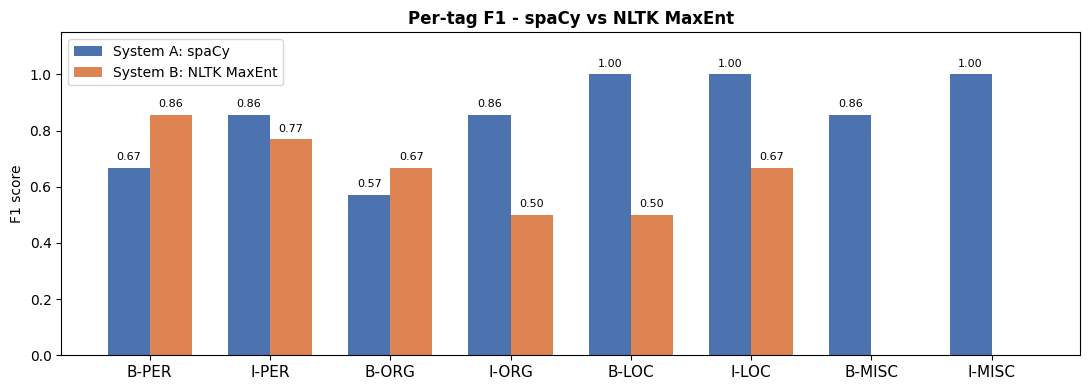

Saved: ner_f1_comparison.png


In [8]:
# -- Grouped F1 bar chart --
labels_plot = ["B-PER","I-PER","B-ORG","I-ORG","B-LOC","I-LOC","B-MISC","I-MISC"]
spacy_f1s = [f1_score(gold_tags, spacy_tags, labels=[l], average="micro", zero_division=0)
             for l in labels_plot]
nltk_f1s  = [f1_score(gold_tags, nltk_tags,  labels=[l], average="micro", zero_division=0)
             for l in labels_plot]

x = np.arange(len(labels_plot)); w = 0.35
fig, ax = plt.subplots(figsize=(11, 4))
b1 = ax.bar(x - w/2, spacy_f1s, w, label="System A: spaCy",       color="#4C72B0")
b2 = ax.bar(x + w/2, nltk_f1s,  w, label="System B: NLTK MaxEnt", color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(labels_plot, fontsize=11)
ax.set_ylabel("F1 score"); ax.set_ylim(0, 1.15)
ax.set_title("Per-tag F1 - spaCy vs NLTK MaxEnt", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x()+bar.get_width()/2., h+0.02,
                f"{h:.2f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig("ner_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ner_f1_comparison.png")

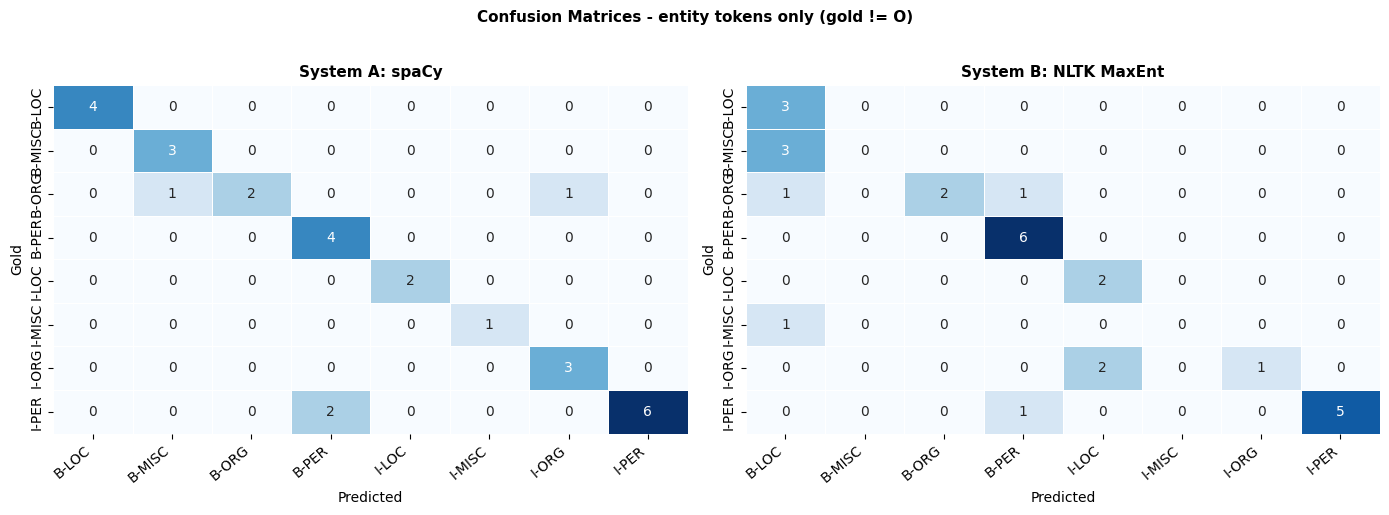

Saved: ner_confusion_matrices.png


In [9]:
# -- Confusion matrices (entity tokens only) --
ent_df = ner_df[ner_df["gold_tag"] != "O"].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in [
    (axes[0], "spacy_tag", "System A: spaCy"),
    (axes[1], "nltk_tag",  "System B: NLTK MaxEnt"),
]:
    cm = confusion_matrix(ent_df["gold_tag"], ent_df[col], labels=ent_labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=ent_labels, yticklabels=ent_labels,
                ax=ax, cbar=False, linewidths=0.5)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Gold")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xticklabels(ent_labels, rotation=40, ha="right")
plt.suptitle("Confusion Matrices - entity tokens only (gold != O)",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("ner_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ner_confusion_matrices.png")

## NERC Error Analysis - Categorised

In [10]:
def categorise_errors(ner_df, pred_col, system_name, ner_sents):
    """Categorise all token-level errors into FN / FP / type confusion / boundary."""
    errors = ner_df[ner_df["gold_tag"] != ner_df[pred_col]]
    cats = {"FN":[], "FP":[], "type":[], "boundary":[]}
    for _, r in errors.iterrows():
        g, p = r["gold_tag"], r[pred_col]
        entry = {"sid": int(r["sentence_id"]), "token": r["token"],
                 "gold": g, "pred": p,
                 "ctx": " ".join(ner_sents[int(r["sentence_id"])]["tokens"])[:60]}
        if   g != "O" and p == "O": cats["FN"].append(entry)
        elif g == "O" and p != "O": cats["FP"].append(entry)
        elif "-" in g and "-" in p:
            g_type = g.split("-")[1]; p_type = p.split("-")[1]
            if g_type != p_type: cats["type"].append(entry)
            else:                cats["boundary"].append(entry)
    total = sum(len(v) for v in cats.values())
    print(f"{'='*65}")
    print(f"{system_name} - {total} token errors")
    print(f"{'='*65}")
    print(f"  False Negatives  (missed entirely):          {len(cats['FN'])}")
    print(f"  False Positives  (hallucinated):             {len(cats['FP'])}")
    print(f"  Type confusions  (right span, wrong type):   {len(cats['type'])}")
    print(f"  Boundary errors  (right type, wrong B/I):    {len(cats['boundary'])}")
    for key, label in [("FN","FALSE NEGATIVES"),("FP","FALSE POSITIVES"),
                       ("type","TYPE CONFUSIONS"),("boundary","BOUNDARY ERRORS")]:
        if cats[key]:
            print(f"  -- {label} --")
            for e in cats[key]:
                print(f"    sent{e['sid']}: '{e['token']}' gold={e['gold']} pred={e['pred']}")
                print(f"      Context: \"{e['ctx']}...\"")
    print()
    return cats

spacy_cats = categorise_errors(ner_df, "spacy_tag", "SYSTEM A - spaCy",       ner_sents)
nltk_cats  = categorise_errors(ner_df, "nltk_tag",  "SYSTEM B - NLTK MaxEnt", ner_sents)

SYSTEM A - spaCy - 7 token errors
  False Negatives  (missed entirely):          2
  False Positives  (hallucinated):             1
  Type confusions  (right span, wrong type):   1
  Boundary errors  (right type, wrong B/I):    3
  -- FALSE NEGATIVES --
    sent7: 'Dame' gold=B-PER pred=O
      Context: "Dame Maggie Smith performed her role excellently , as she do..."
    sent8: 'Mr.' gold=B-PER pred=O
      Context: "The new movie by Mr. Kruno was shot in New York , but the st..."
  -- FALSE POSITIVES --
    sent1: 'the' gold=O pred=B-ORG
      Context: "All the New York University students love this diner in Soho..."
  -- TYPE CONFUSIONS --
    sent6: 'Blauwbrug' gold=B-ORG pred=B-MISC
      Context: "My husband and I moved to Amsterdam 6 years ago and for as l..."
  -- BOUNDARY ERRORS --
    sent1: 'New' gold=B-ORG pred=I-ORG
      Context: "All the New York University students love this diner in Soho..."
    sent7: 'Maggie' gold=I-PER pred=B-PER
      Context: "Dame Maggie Smith pe

In [11]:
# -- Where systems disagree - the most informative comparison --
disagree = ner_df[ner_df["spacy_tag"] != ner_df["nltk_tag"]]
sp_only  = disagree[ disagree["spacy_correct"] & ~disagree["nltk_correct"]]
nl_only  = disagree[~disagree["spacy_correct"] &  disagree["nltk_correct"]]
both_w   = disagree[~disagree["spacy_correct"] & ~disagree["nltk_correct"]]

print(f"Tokens where systems DISAGREE: {len(disagree)}")
print(f"  Only spaCy correct: {len(sp_only)}")
print(f"  Only NLTK correct:  {len(nl_only)}")
print(f"  Both wrong:         {len(both_w)}\n")

print(f"{'Token':<15} {'Gold':<10} {'spaCy':<10} {'NLTK':<10} {'sp_ok':<5} {'nl_ok'}")
print("-"*58)
for _, r in disagree.iterrows():
    print(f"  {r['token']:<13} {r['gold_tag']:<10} {r['spacy_tag']:<10} "
          f"{r['nltk_tag']:<10} "
          f"{'1' if r['spacy_correct'] else '0':<5} "
          f"{'1' if r['nltk_correct'] else '0'}")

Tokens where systems DISAGREE: 15
  Only spaCy correct: 9
  Only NLTK correct:  4
  Both wrong:         2

Token           Gold       spaCy      NLTK       sp_ok nl_ok
----------------------------------------------------------
  the           O          B-ORG      O          0     1
  New           B-ORG      I-ORG      B-LOC      0     0
  York          I-ORG      I-ORG      I-LOC      1     0
  University    I-ORG      I-ORG      I-LOC      1     0
  Italian       B-MISC     B-MISC     B-LOC      1     0
  Jr.           I-PER      I-PER      O          1     0
  African       B-MISC     B-MISC     B-LOC      1     0
  American      I-MISC     I-MISC     B-LOC      1     0
  O'Donnell     I-PER      I-PER      O          1     0
  Amsterdam     B-LOC      B-LOC      O          1     0
  Blauwbrug     B-ORG      B-MISC     B-PER      0     0
  Dame          B-PER      O          B-PER      0     1
  Mr.           B-PER      O          B-PER      0     1
  Kruno         I-PER      B-PER

## NERC Qualitative Error Analysis

All claims below are read directly from the token-level output of the two systems on the 10 test sentences (the disagreement table and the categorised-error breakdown above).

**1. Blauwbrug (sent 6, gold B-ORG) - both systems wrong, differently.** spaCy -> B-MISC (type confusion); NLTK -> B-PER (type confusion), and NLTK also drops "Amsterdam" entirely (false negative) in the same sentence. Root cause: an out-of-vocabulary Dutch restaurant name. Neither OntoNotes (spaCy) nor ACE 2004 (NLTK) contains it, so each falls back to its default guess for an unknown capitalised word - MISC for spaCy, PER for NLTK.

**2. New York University (sent 1, gold B-ORG I-ORG I-ORG) - global vs local context.** NLTK tags all three tokens as LOC: its MaxEnt model reads a narrow local window, "New York" looks like a place, and it cannot look ahead to "University" to revise the type. spaCy gets the ORG type right but mis-sets the left boundary, tagging "the New York University" as one span ("the" -> B-ORG false positive, "New" -> I-ORG instead of B-ORG). So NLTK fails on type; spaCy fails only on the span boundary.

**3. African American (sent 4, gold B-MISC I-MISC) - NORP handling.** spaCy is correct: it reads the pair as a single NORP (ethnic/demographic) entity, mapped to MISC. NLTK tags both tokens as LOC and splits them into two entities; it has no MISC/NORP concept and matches the geographic surface form instead.

**4. Honorific titles: Dame (sent 7) and Mr. (sent 8) - NLTK actually wins here.** spaCy drops both titles (Dame -> O, Mr. -> O, false negatives) and then mis-bounds the following name (Maggie -> B-PER, Kruno -> B-PER instead of I-PER). NLTK includes the title in the person span: it tags "Mr. Kruno" completely correctly and gets "Dame" right (only mis-bounding "Maggie"). This is the clearest case where the classical system beats the neural one.

**5. O'Donnell (sent 5, gold I-PER) - apostrophe tokenisation.** spaCy is correct (I-PER). NLTK returns O (false negative): its POS step splits "O'Donnell" on the apostrophe, breaking the feature window so the chunker never forms the entity.

**6. MISC is NLTK's blind spot, not spaCy's.** On B-MISC and I-MISC, NLTK scores F1 = 0.00 - it sends every nationality/cultural adjective (Italian, African, American, English) to LOC, because ACE has no MISC label. spaCy handles MISC well (B-MISC recall 1.00) thanks to the NORP -> MISC mapping. This single label difference is the biggest driver of the overall gap.

### Why spaCy wins overall (96.7% vs 94.4% token accuracy; macro-F1 0.85 vs 0.49)
The dominant factor is the label schema: NLTK has no MISC equivalent, so it loses the entire MISC class to LOC. Global sentence context is a secondary advantage (it resolves "New York University" as ORG). NLTK's one genuine strength is including honorific titles in PER spans, where spaCy drops them.

### Improvement suggestions
1. dslim/bert-base-NER: subword tokenisation handles "Blauwbrug" and apostrophes.
2. Fine-tune on CoNLL-2003 to align the label schema (fixes the MISC gap).
3. A domain gazetteer for restaurant names and film titles.
4. For NLTK: replace MaxEnt with a CRF for sequence-level (not local) decisions.

---
# Section 2 - Sentiment Analysis: Two-System Deep-Dive

## Task
Classify each sentence as positive | neutral | negative at the sentence level.

This section mirrors the two-system structure of Section 1 (NERC): we run and directly
compare two unsupervised, lexicon/rule-based sentiment systems on the same 10 test
sentences. Neither uses training data, so the comparison is a clean test of two
different lexicon-design philosophies.

## System A - VADER (Valence Aware Dictionary and sEntiment Reasoner)
Hutto and Gilbert (2014). A rule-based system built for short social-media text.
- Lexicon of ~7,500 crowd-rated terms, each with a valence in [-4, +4], normalised to a compound score in [-1, +1].
- Five heuristics: ALL-CAPS amplification, punctuation (`!`) boosting, degree modifiers ("very", "barely"), single-token negation flipping, and a contrastive "but" rule.
- Decision boundary: compound >= 0.05 -> positive, <= -0.05 -> negative, else neutral.

## System B - TextBlob (Pattern lexicon)
Loria (2018); De Smedt and Daelemans (2012). TextBlob's sentiment engine is adapted from the Pattern library.
- Lexicon of ~2,900 mostly-adjective entries scraped from review sites; each carries a polarity in [-1, +1] and a subjectivity in [0, 1].
- Polarity is the simple average of matched-token polarities (no punctuation or CAPS rules; only partial phrase-level negation).
- Subjectivity (0 = factual, 1 = opinionated) is unique to TextBlob and has no VADER equivalent.
- Decision boundary (same thresholds as VADER for a fair comparison): polarity > 0.05 -> positive, < -0.05 -> negative, else neutral.

## What we expect them to disagree on
| Dimension | System A - VADER | System B - TextBlob |
|---|---|---|
| Architecture | Rule-based lexicon + heuristics | Pattern-lexicon averaging |
| Lexicon source | Crowd-rated (MTurk) | Review corpora (Rotten Tomatoes, Amazon) |
| Lexicon size | ~7,500 terms | ~2,900 adjective-focused |
| Polarity computation | Weighted compound (normalised) | Mean over matched tokens |
| Subjectivity | Not modelled | Explicit score in [0, 1] |
| Negation | Single-token flip rule | Partial phrase chunks |
| Punctuation / CAPS | Yes | No |
| Design target | Social media | General English reviews |

Averaging (TextBlob) dilutes a single strong word, while VADER's compound is dominated by it - so the two are expected to diverge on sentences driven by one high-valence token, on factual sentences, and on idiomatic negation.

In [12]:
analyzer = SentimentIntensityAnalyzer()

def vader_predict(text):
    sc = analyzer.polarity_scores(text)
    c  = sc["compound"]
    label = "positive" if c >= 0.05 else "negative" if c <= -0.05 else "neutral"
    return label, sc

vader_results     = [vader_predict(t) for t in TEXTS]
vader_preds       = [r[0] for r in vader_results]
vader_scores_list = [r[1] for r in vader_results]

sent_df["vader_pred"]     = vader_preds
sent_df["vader_compound"] = [round(s["compound"], 4) for s in vader_scores_list]
print("VADER complete | >=0.05=positive | <=-0.05=negative | else=neutral")

VADER complete | >=0.05=positive | <=-0.05=negative | else=neutral


In [13]:
# -- System B: TextBlob sentiment prediction --
from textblob import TextBlob

def textblob_predict(text):
    """Classify with TextBlob polarity; thresholds mirror VADER for fairness.
    Returns (label, Sentiment(polarity, subjectivity))."""
    s = TextBlob(text).sentiment
    label = "positive" if s.polarity > 0.05 else "negative" if s.polarity < -0.05 else "neutral"
    return label, s

tb_results    = [textblob_predict(t) for t in TEXTS]
tb_preds      = [r[0] for r in tb_results]
tb_sentiments = [r[1] for r in tb_results]

sent_df["textblob_pred"]         = tb_preds
sent_df["textblob_polarity"]     = [round(s.polarity, 4)     for s in tb_sentiments]
sent_df["textblob_subjectivity"] = [round(s.subjectivity, 4) for s in tb_sentiments]

print("System B (TextBlob) complete | polarity>0.05=positive | <-0.05=negative | else=neutral")
print(f"Label distribution: {dict(pd.Series(tb_preds).value_counts())}")

System B (TextBlob) complete | polarity>0.05=positive | <-0.05=negative | else=neutral
Label distribution: {'positive': 8, 'neutral': 2}


## Sentiment Results - VADER vs TextBlob

In [14]:
# -- Combined evaluation: accuracy, reports, side-by-side table (1=correct, 0=wrong) --
labels_3  = ["positive", "neutral", "negative"]
vader_acc = accuracy_score(GOLD_SENT, vader_preds)
tb_acc    = accuracy_score(GOLD_SENT, tb_preds)
v_correct = sum(g == p for g, p in zip(GOLD_SENT, vader_preds))
t_correct = sum(g == p for g, p in zip(GOLD_SENT, tb_preds))

print("="*60)
print("  SENTIMENT EVALUATION - System A (VADER) vs System B (TextBlob)")
print("="*60)
print(f"  System A (VADER):    {vader_acc:.0%}  ({v_correct}/10 correct)")
print(f"  System B (TextBlob): {tb_acc:.0%}  ({t_correct}/10 correct)")
print()
print("System A - VADER classification report")
print(classification_report(GOLD_SENT, vader_preds, labels=labels_3, zero_division=0))
print("System B - TextBlob classification report")
print(classification_report(GOLD_SENT, tb_preds, labels=labels_3, zero_division=0))

print(f"{'ID':>2} {'Gold':<9} {'VADER':<9} {'TextBlob':<9} {'V-cpd':>7} {'TB-pol':>7} {'TB-subj':>7}  {'V':>1} {'T':>1}")
print("-"*72)
for _, row in sent_df.iterrows():
    g  = row["sentiment"]
    vp = row["vader_pred"]; tp = row["textblob_pred"]
    v  = "1" if vp == g else "0"
    t  = "1" if tp == g else "0"
    print(f"{int(row['sentence id']):>2} {g:<9} {vp:<9} {tp:<9} "
          f"{row['vader_compound']:>7.3f} {row['textblob_polarity']:>7.3f} "
          f"{row['textblob_subjectivity']:>7.2f}  {v:>1} {t:>1}")

  SENTIMENT EVALUATION - System A (VADER) vs System B (TextBlob)
  System A (VADER):    60%  (6/10 correct)
  System B (TextBlob): 50%  (5/10 correct)

System A - VADER classification report
              precision    recall  f1-score   support

    positive       0.50      1.00      0.67         4
     neutral       1.00      0.33      0.50         3
    negative       1.00      0.33      0.50         3

    accuracy                           0.60        10
   macro avg       0.83      0.56      0.56        10
weighted avg       0.80      0.60      0.57        10

System B - TextBlob classification report
              precision    recall  f1-score   support

    positive       0.50      1.00      0.67         4
     neutral       0.50      0.33      0.40         3
    negative       0.00      0.00      0.00         3

    accuracy                           0.50        10
   macro avg       0.33      0.44      0.36        10
weighted avg       0.35      0.50      0.39        10

ID Go

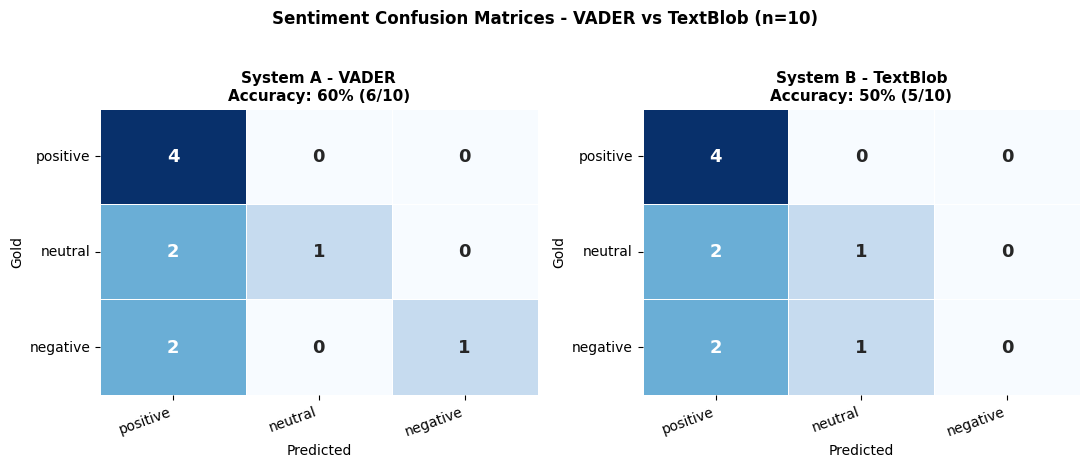

Saved: sentiment_confusion_comparison.png


In [15]:
# -- Side-by-side confusion matrices --
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, preds, name, acc, corr in [
    (axes[0], vader_preds, "System A - VADER",    vader_acc, v_correct),
    (axes[1], tb_preds,    "System B - TextBlob", tb_acc,    t_correct),
]:
    cm = confusion_matrix(GOLD_SENT, preds, labels=labels_3)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_3, yticklabels=labels_3,
                ax=ax, cbar=False, linewidths=0.6,
                annot_kws={"size": 13, "weight": "bold"})
    ax.set_xlabel("Predicted"); ax.set_ylabel("Gold")
    ax.set_title(f"{name}\nAccuracy: {acc:.0%} ({corr}/10)", fontsize=11, fontweight="bold")
    ax.set_xticklabels(labels_3, rotation=20, ha="right")
    ax.set_yticklabels(labels_3, rotation=0)
fig.suptitle("Sentiment Confusion Matrices - VADER vs TextBlob (n=10)",
             fontsize=12, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("sentiment_confusion_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sentiment_confusion_comparison.png")

## Sentiment Error Analysis - Two-System Investigation

We analyse failures for both systems. For each misclassified sentence we (1) identify the
responsible lexical items, (2) name the failure type, and (3) connect it to the system
mechanism. The token-level VADER scores below are followed by the cross-system agreement
breakdown and a compound-vs-polarity scatter plot.

### Failure taxonomy
| Type | Description | VADER mechanism | TextBlob mechanism |
|---|---|---|---|
| A - Factual framing | Descriptive sentence, incidentally high-valence words | No discourse model; lexicon fires out of context | Low subjectivity, but polarity can still be non-zero |
| B - Idiomatic negation | Negative meaning carried by an idiom in neither lexicon | Negation rule only flips one following token | Phrase chunks miss multi-word idioms |
| C - Single-word domination | One strong word decides the sentence | Compound is dominated by it | Averaging dilutes it (can help or hurt) |
| D - Reported speech | Feeling attributed to a third party, not the reviewer | Cannot distinguish "he felt X" from "I feel X" | Same; no stance model |

In [16]:
# -- Step 1: Print individual token scores for every error sentence --
print("TOKEN-LEVEL VALENCE SCORES FOR MISCLASSIFIED SENTENCES")
print("="*65)
print("(Only tokens with non-zero compound score are shown)\n")

vader_errors = [(i, row) for i, row in sent_df.iterrows()
                if row["vader_pred"] != row["sentiment"]]

for i, row in vader_errors:
    sid  = int(row["sentence id"])
    sc   = vader_scores_list[sid]
    text = row["text"]
    print(f'Sent {sid} | Gold: {row["sentiment"]:8s} | VADER: {row["vader_pred"]:8s}')
    print(f'  neg={sc["neg"]:.2f}  neu={sc["neu"]:.2f}  pos={sc["pos"]:.2f}  compound={sc["compound"]:.4f}')
    print(f'  Text: "{text[:80]}"')
    print()
    # Token-level scores
    print("  Token valence breakdown:")
    for word in text.split():
        clean = word.strip(".,!?;:\"'").lower()
        ws    = analyzer.polarity_scores(clean)["compound"]
        if ws != 0.0:
            print(f"    '{word}'  ->  {ws:+.3f}")
    print()

TOKEN-LEVEL VALENCE SCORES FOR MISCLASSIFIED SENTENCES
(Only tokens with non-zero compound score are shown)

Sent 2 | Gold: negative | VADER: positive
  neg=0.10  neu=0.78  pos=0.12  compound=0.0745
  Text: "This Italian place is really trendy but they have forgotten about the most impor"

  Token valence breakdown:
    'forgotten'  ->  -0.226
    'important'  ->  +0.202

Sent 4 | Gold: neutral  | VADER: positive
  neg=0.00  neu=0.84  pos=0.16  compound=0.6124
  Text: "The story of this movie is focused on Carl Brashear played by Cuba Gooding Jr. w"

  Token valence breakdown:
    'focused'  ->  +0.382
    'played'  ->  +0.340

Sent 5 | Gold: neutral  | VADER: positive
  neg=0.00  neu=0.87  pos=0.13  compound=0.3612
  Text: "Chris O'Donnell stated that while filming for this movie, he felt like he was in"

  Token valence breakdown:
    'like'  ->  +0.361

Sent 9 | Gold: negative | VADER: positive
  neg=0.00  neu=0.84  pos=0.16  compound=0.3506
  Text: "I always have loved English nove

  CROSS-SYSTEM AGREEMENT

BOTH CORRECT (4/10):
  S1: gold=positive  VADER=positive (cpd +0.818)  TextBlob=positive (pol +0.259, subj 0.41)
  S3: gold=positive  VADER=positive (cpd +0.361)  TextBlob=positive (pol +0.500, subj 1.00)
  S6: gold=positive  VADER=positive (cpd +0.509)  TextBlob=positive (pol +0.287, subj 0.70)
  S7: gold=positive  VADER=positive (cpd +0.625)  TextBlob=positive (pol +1.000, subj 1.00)

BOTH WRONG (3/10):
  S2: gold=negative  VADER=positive (cpd +0.074)  TextBlob=positive (pol +0.375, subj 0.60)
  S4: gold=neutral   VADER=positive (cpd +0.612)  TextBlob=positive (pol +0.090, subj 0.17)
  S9: gold=negative  VADER=positive (cpd +0.351)  TextBlob=positive (pol +0.350, subj 0.40)

ONLY VADER CORRECT (2/10):
  S0: gold=negative  VADER=negative (cpd -0.625)  TextBlob=neutral  (pol +0.000, subj 0.00)
  S8: gold=neutral   VADER=neutral  (cpd +0.000)  TextBlob=positive (pol +0.136, subj 0.45)

ONLY TEXTBLOB CORRECT (1/10):
  S5: gold=neutral   VADER=positive (cpd +0.36

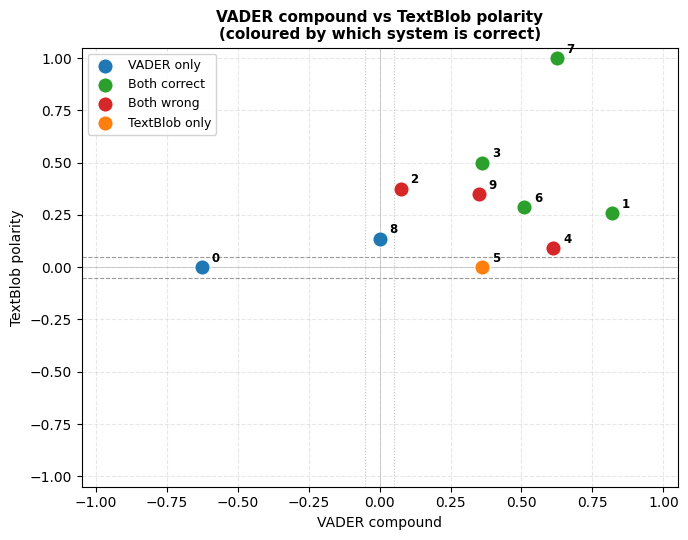

Saved: sentiment_compound_vs_polarity.png


In [17]:
# -- Cross-system agreement and disagreement analysis --
v_ok = [p == g for p, g in zip(vader_preds, GOLD_SENT)]
t_ok = [p == g for p, g in zip(tb_preds,    GOLD_SENT)]
both_right = [i for i in range(10) if     v_ok[i] and     t_ok[i]]
both_wrong = [i for i in range(10) if not v_ok[i] and not t_ok[i]]
only_vader = [i for i in range(10) if     v_ok[i] and not t_ok[i]]
only_tb    = [i for i in range(10) if not v_ok[i] and     t_ok[i]]
disagree   = [i for i in range(10) if vader_preds[i] != tb_preds[i]]

def _line(i):
    r = sent_df.iloc[i]
    return (f"  S{int(r['sentence id'])}: gold={GOLD_SENT[i]:<9} "
            f"VADER={vader_preds[i]:<9}(cpd {r['vader_compound']:+.3f})  "
            f"TextBlob={tb_preds[i]:<9}(pol {r['textblob_polarity']:+.3f}, subj {r['textblob_subjectivity']:.2f})")

print("="*70)
print("  CROSS-SYSTEM AGREEMENT")
print("="*70)
for name, idxs in [("BOTH CORRECT", both_right), ("BOTH WRONG", both_wrong),
                   ("ONLY VADER CORRECT", only_vader), ("ONLY TEXTBLOB CORRECT", only_tb)]:
    print(f"\n{name} ({len(idxs)}/10):")
    for i in idxs:
        print(_line(i))
    if not idxs:
        print("  (none)")

print("\n" + "="*70)
print(f"  DISAGREEMENTS ({len(disagree)} sentences where VADER != TextBlob)")
print("="*70)
for i in disagree:
    r = sent_df.iloc[i]
    winner = "VADER" if v_ok[i] else "TextBlob" if t_ok[i] else "neither"
    print(_line(i) + f"  -> winner: {winner}")
    print(f"     Text: \"{r['text'][:75]}\"")

# TextBlob subjectivity vs correctness
tb_err = [i for i in range(10) if not t_ok[i]]
tb_cor = [i for i in range(10) if     t_ok[i]]
print("\n" + "="*70)
print("  TEXTBLOB: subjectivity vs correctness")
print("="*70)
print(f"  Correct predictions - mean subjectivity: {np.mean([sent_df.iloc[i]['textblob_subjectivity'] for i in tb_cor]):.3f} (n={len(tb_cor)})")
print(f"  Wrong predictions   - mean subjectivity: {np.mean([sent_df.iloc[i]['textblob_subjectivity'] for i in tb_err]):.3f} (n={len(tb_err)})")

# Compound vs polarity scatter, coloured by which system is correct
fig, ax = plt.subplots(figsize=(7, 5.5))
cmap = {(True,True):("#2ca02c","Both correct"), (False,False):("#d62728","Both wrong"),
        (True,False):("#1f77b4","VADER only"), (False,True):("#ff7f0e","TextBlob only")}
seen = set()
for i in range(10):
    col, lab = cmap[(v_ok[i], t_ok[i])]
    r = sent_df.iloc[i]
    ax.scatter(r["vader_compound"], r["textblob_polarity"], c=col, s=120, zorder=5,
               edgecolors="white", linewidth=0.8, label=lab if lab not in seen else None)
    ax.annotate(str(int(r["sentence id"])), (r["vader_compound"], r["textblob_polarity"]),
                textcoords="offset points", xytext=(7, 4), fontsize=8.5, fontweight="bold")
    seen.add(lab)
for y in (0.05, -0.05): ax.axhline(y, color="#555", ls="--", lw=0.8, alpha=0.6)
for x in (0.05, -0.05): ax.axvline(x, color="#999", ls=":",  lw=0.8, alpha=0.6)
ax.axhline(0, color="#bbb", lw=0.5); ax.axvline(0, color="#bbb", lw=0.5)
ax.set_xlabel("VADER compound"); ax.set_ylabel("TextBlob polarity")
ax.set_title("VADER compound vs TextBlob polarity\n(coloured by which system is correct)",
             fontsize=11, fontweight="bold")
ax.legend(loc="upper left", fontsize=9, framealpha=0.85)
ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.05, 1.05); ax.grid(True, ls="--", alpha=0.3)
plt.tight_layout()
plt.savefig("sentiment_compound_vs_polarity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sentiment_compound_vs_polarity.png")

## Sentiment Categorised Error Analysis

On these 10 sentences VADER scores 6/10 and TextBlob 5/10, so **TextBlob is not more
accurate here** - but the comparison is informative because the two systems fail on
*different* sentences. They agree on 7 sentences and disagree on 3 (S0, S5, S8).

### Both correct (S1, S3, S6, S7)
Clearly positive review sentences with overt sentiment that both lexicons cover
("love", "like", "excellently"). These are the easy cases.

### Both wrong (S2, S4, S9) - shared blind spots
- **S2** ("...really trendy but they have forgotten about the most important part... the food", gold negative): VADER +0.074, TextBlob +0.375. The negative meaning is compositional ("forgotten about the food"); both lexicons see only "trendy"/"important" as positive. Type B/C.
- **S4** ("The story of this movie is focused on Carl Brashear played by...", gold neutral): a plot description. VADER +0.612 (driven by "focused"/"played"); TextBlob +0.090 - much weaker because averaging dilutes those verbs, but still over the threshold. Type A.
- **S9** ("I always have loved English novels, but I just couldn't get into this one", gold negative): "loved" dominates both (VADER +0.351, TextBlob +0.350); the rejection idiom "couldn't get into this one" is in neither lexicon. Type B/C.

### Only VADER correct (S0, S8) - where TextBlob's narrow lexicon hurts
- **S0** ("...recover from the disaster that was this movie", gold negative): VADER catches "disaster" (-0.625, correct). TextBlob returns polarity 0.000 (neutral, wrong) - "disaster" is a noun, and Pattern's adjective-focused lexicon never scores it.
- **S8** ("The new movie by Mr. Kruno was shot in New York...", gold neutral): VADER 0.000 (neutral, correct). TextBlob +0.136 (positive, wrong) because Pattern scores "new" as mildly positive. Note its subjectivity is 0.45 - a confidence gate would not have caught this.

### Only TextBlob correct (S5) - where averaging helps
- **S5** ("Chris O'Donnell stated that... he felt like he was in a toy commercial", gold neutral): VADER +0.361 (positive, wrong) because it scores the comparison word "like" as the positive verb. TextBlob returns polarity 0.000 (neutral, correct) - it does not treat "like" as sentiment here. This is the one case where TextBlob's conservative averaging avoids a VADER false positive. Type D (reported speech) for VADER.

### Pattern and root cause
Both systems over-predict positive (every error is a false positive toward positive).
VADER is more sensitive (broader lexicon, compound weighting) so it catches strong
negatives like "disaster" but is also fooled by single positive tokens ("like",
"focused"). TextBlob's averaging is more conservative - it avoids one VADER mistake
but misses negatives its narrow adjective lexicon does not contain. The subjectivity
score is appealing in principle but does not separate errors from correct cases here
(see the printed means), so it is not a reliable confidence gate on this set.

### Improvement suggestions
1. A fine-tuned transformer (e.g. cardiffnlp/twitter-roberta-base-sentiment) encodes full context, handles idioms and reported speech, and would address the shared Type A/B/D failures.
2. Add idiomatic multi-word units ("couldn't get into", "forgotten about") to either lexicon.
3. For TextBlob: extend the lexicon beyond adjectives to sentiment-bearing nouns/verbs ("disaster", "loved") to fix S0-type misses.
4. For VADER: raise the positive threshold or add a reported-speech/factual detector to suppress S4/S5-type false positives.

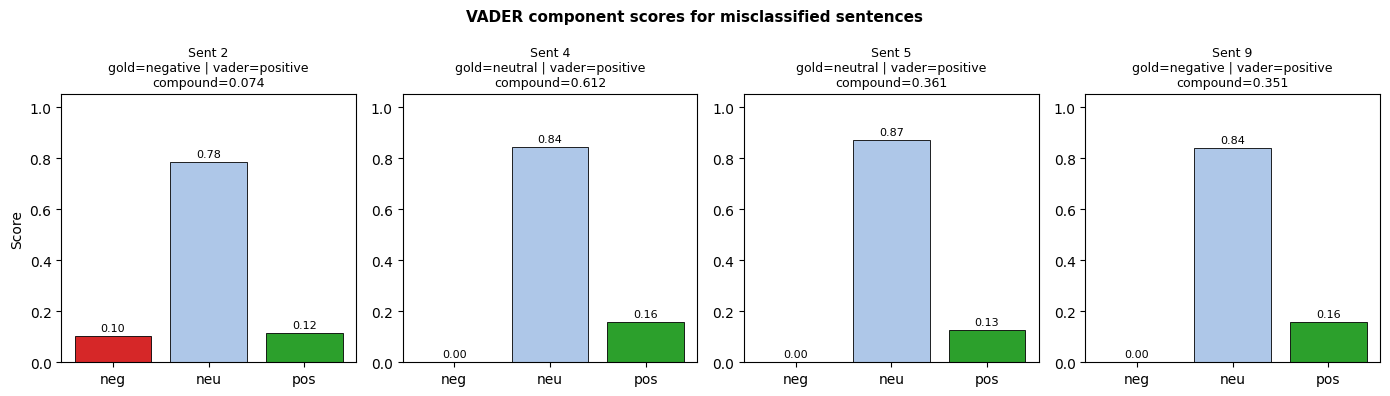

Saved: sentiment_error_breakdown.png


In [18]:
# -- Score breakdown visualisation for error sentences --
error_sids = [int(row["sentence id"]) for _, row in vader_errors]
fig, axes  = plt.subplots(1, len(error_sids), figsize=(14, 4), sharey=False)

for ax, sid in zip(axes, error_sids):
    sc    = vader_scores_list[sid]
    cats  = ["neg","neu","pos"]
    vals  = [sc[c] for c in cats]
    colors = ["#d62728","#aec7e8","#2ca02c"]
    ax.bar(cats, vals, color=colors, edgecolor="black", linewidth=0.6)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Sent {sid}\ngold={GOLD_SENT[sid]} | vader={vader_preds[sid]}\ncompound={sc['compound']:.3f}",
                 fontsize=9)
    ax.set_ylabel("Score" if sid == error_sids[0] else "")
    for i, v in enumerate(vals):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)

plt.suptitle("VADER component scores for misclassified sentences", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("sentiment_error_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sentiment_error_breakdown.png")

---
# Section 3 - Topic Classification (Supervised SVM)

Sentence-level topic labelling into movie / restaurant / book using a TF-IDF + linear-SVM classifier trained on NLTK corpora.

In [19]:
print("Building sentence-level topic training corpus...\n")

movie_sents_t = []
for fid in movie_reviews.fileids():
    text = " ".join(movie_reviews.words(fid))
    movie_sents_t.extend([
        s for s in sent_tokenize(text) if 5 <= len(s.split()) <= 60
    ])
print(f"Movie:      {len(movie_sents_t):>7,} (NLTK movie_reviews)")

book_sents_t = []
for fname in ["austen-emma.txt","melville-moby_dick.txt","carroll-alice.txt",
              "chesterton-ball.txt","shakespeare-hamlet.txt",
              "austen-persuasion.txt","chesterton-brown.txt","edgeworth-parents.txt"]:
    text = " ".join(gutenberg.words(fname))
    book_sents_t.extend([
        s for s in sent_tokenize(text) if 5 <= len(s.split()) <= 60
    ])
print(f"Book:       {len(book_sents_t):>7,} (NLTK Gutenberg - 8 literary works)")

FOOD_KWS = {"food","eating","meal","dinner","lunch","restaurant","menu","chef",
            "taste","service","waiter","waitress","diner","cuisine","wine","coffee",
            "breakfast","cook","cooking","kitchen","dining","cafe","drink",
            "delicious","flavor","flavour","portion","appetite","bistro"}

rest_text_rev = " ".join(" ".join(s) for s in brown.sents(categories="reviews"))
rest_sents_t  = [s for s in sent_tokenize(rest_text_rev) if 5 <= len(s.split()) <= 60]
hobby_text    = " ".join(" ".join(s) for s in brown.sents(categories="hobbies"))
hobby_food    = [s for s in sent_tokenize(hobby_text)
                 if any(kw in s.lower().split() for kw in FOOD_KWS)
                 and 5 <= len(s.split()) <= 60]
rest_sents_t  = rest_sents_t + hobby_food
print(f"Restaurant: {len(rest_sents_t):>7,} (Brown reviews + food-filtered hobbies)")
print()
print("Note: Gutenberg = text FROM books (narrative prose), not text ABOUT books.")
print("This distinction affects classifier behaviour - see error analysis.")

Building sentence-level topic training corpus...



Movie:       63,379 (NLTK movie_reviews)


Book:        38,740 (NLTK Gutenberg - 8 literary works)


Restaurant:   1,641 (Brown reviews + food-filtered hobbies)

Note: Gutenberg = text FROM books (narrative prose), not text ABOUT books.
This distinction affects classifier behaviour - see error analysis.


In [20]:
n_per_class_t = min(1500, len(movie_sents_t), len(book_sents_t), len(rest_sents_t))
X_topic = (random.sample(movie_sents_t, n_per_class_t) +
           random.sample(book_sents_t,  n_per_class_t) +
           random.sample(rest_sents_t,  n_per_class_t))
y_topic = (["movie"]      * n_per_class_t +
           ["book"]       * n_per_class_t +
           ["restaurant"] * n_per_class_t)

print(f"Training corpus: {len(X_topic):,} sentences ({n_per_class_t} per class)")

svm_topic = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features  = 15000,
        stop_words    = "english",
        ngram_range   = (1, 2),
        sublinear_tf  = True,
    )),
    ("svm", LinearSVC(C=1.0, max_iter=2000, class_weight="balanced")),
])
svm_topic.fit(X_topic, y_topic)
topic_preds  = list(svm_topic.predict(TEXTS))
topic_scores = svm_topic.decision_function(TEXTS)
topic_classes = list(svm_topic["svm"].classes_)
sent_df["topic_pred"] = topic_preds

print(f"Topic SVM trained | vocab: {len(svm_topic['tfidf'].vocabulary_):,} terms")
print(f"   Classes: {topic_classes}")

Training corpus: 4,500 sentences (1500 per class)


Topic SVM trained | vocab: 15,000 terms
   Classes: ['book', 'movie', 'restaurant']


## Topic Evaluation

In [21]:
topic_labels = ["movie", "restaurant", "book"]
topic_acc    = accuracy_score(GOLD_TOPIC, topic_preds)
print(f"Topic SVM accuracy: {topic_acc:.0%} "
      f"({sum(g==p for g,p in zip(GOLD_TOPIC,topic_preds))}/10)")
print(classification_report(GOLD_TOPIC, topic_preds, labels=topic_labels, zero_division=0))

print(f"\n{'ID':>2} {'Gold':<12} {'Predicted':<12} {'ok':>3}  Decision scores")
print("-"*72)
for i, (row, scores) in enumerate(zip(sent_df.itertuples(), topic_scores)):
    ok = "1" if topic_preds[i] == GOLD_TOPIC[i] else "0"
    sc = " ".join([f"{c}:{s:.2f}" for c, s in zip(topic_classes, scores)])
    print(f"{i:>2} {GOLD_TOPIC[i]:<12} {topic_preds[i]:<12} {ok:>3}  {sc}")

Topic SVM accuracy: 90% (9/10)
              precision    recall  f1-score   support

       movie       0.83      1.00      0.91         5
  restaurant       1.00      1.00      1.00         3
        book       1.00      0.50      0.67         2

    accuracy                           0.90        10
   macro avg       0.94      0.83      0.86        10
weighted avg       0.92      0.90      0.89        10


ID Gold         Predicted     ok  Decision scores
------------------------------------------------------------------------
 0 movie        movie          1  book:-1.24 movie:1.09 restaurant:-0.98
 1 restaurant   restaurant     1  book:-1.34 movie:0.07 restaurant:0.22
 2 restaurant   restaurant     1  book:-1.19 movie:-1.29 restaurant:1.39
 3 book         book           1  book:0.31 movie:-0.46 restaurant:-0.91
 4 movie        movie          1  book:-1.55 movie:1.56 restaurant:-1.25
 5 movie        movie          1  book:-0.89 movie:1.41 restaurant:-1.68
 6 restaurant   restaurant 

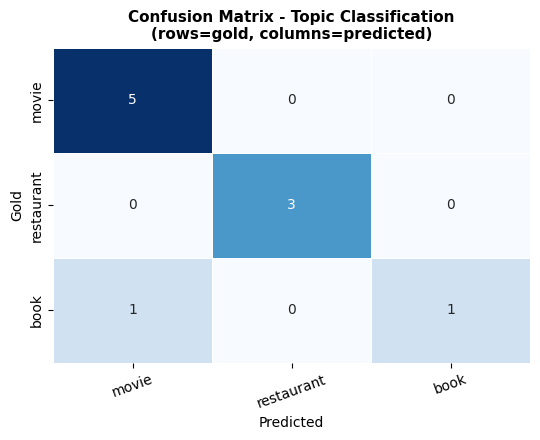

Saved: topic_confusion.png


In [22]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
cm = confusion_matrix(GOLD_TOPIC, topic_preds, labels=topic_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=topic_labels, yticklabels=topic_labels,
            ax=ax, cbar=False, linewidths=0.5)
ax.set_xlabel("Predicted"); ax.set_ylabel("Gold")
ax.set_title("Confusion Matrix - Topic Classification\n(rows=gold, columns=predicted)",
             fontsize=11, fontweight="bold")
ax.set_xticklabels(topic_labels, rotation=20)
plt.tight_layout()
plt.savefig("topic_confusion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: topic_confusion.png")

## Topic Error Analysis

In [23]:
print("="*70)
print("TOPIC ERROR ANALYSIS - Supervised SVM")
print("="*70)
topic_errors = [(i, row) for i, row in sent_df.iterrows()
                if row["topic_pred"] != row["topic"]]
print(f"\nErrors: {len(topic_errors)}/10\n")

feat_names_t = np.array(svm_topic["tfidf"].get_feature_names_out())
coefs_t      = svm_topic["svm"].coef_

for i, row in topic_errors:
    sid = int(row["sentence id"])
    print(f'Sent {sid}: "{row["text"][:78]}"')
    print(f"  Gold: {row['topic']} | SVM predicted: {row['topic_pred']}")
    sc = dict(zip(topic_classes, topic_scores[sid]))
    print(f"  Decision scores: {', '.join(f'{k}={v:.3f}' for k,v in sc.items())}")
    vec  = svm_topic["tfidf"].transform([row["text"]])
    nz   = vec.nonzero()[1]
    pred_ci = topic_classes.index(row["topic_pred"])
    gold_ci = topic_classes.index(row["topic"])
    pred_act = sorted([(feat_names_t[j], float(coefs_t[pred_ci, j]))
                        for j in nz], key=lambda x: -abs(x[1]))[:6]
    gold_act = sorted([(feat_names_t[j], float(coefs_t[gold_ci, j]))
                        for j in nz], key=lambda x: -x[1])[:4]
    print(f"  Tokens  ->  '{row['topic_pred']}': {[(w,round(c,2)) for w,c in pred_act]}")
    print(f"  Tokens  ->  '{row['topic']}':      {[(w,round(c,2)) for w,c in gold_act]}")
    print()
    print(f"  ROOT CAUSE ANALYSIS:")
    print(f"  The gold label is 'book' but the system predicts '{row['topic_pred']}'.")
    print(f"  The book training data comes from GUTENBERG - sentences FROM books")
    print(f"  (narrative prose: 'said he', 'she replied', 'whale') - NOT sentences")
    print(f"  ABOUT books ('I loved this novel', 'the author writes').")
    print(f"  The test sentence is a review ABOUT a book. 'novels' does not strongly")
    print(f"  predict 'book' because Gutenberg characters never discuss novels-as-objects.")
    print(f"  Meanwhile, 'just' and 'couldn' have high movie coefficients because")
    print(f"  these tokens appear frequently in negative movie reviews.")
    print(f"  This error demonstrates how CORPUS COMPOSITION determines classifier")
    print(f"  behaviour - a core principle of corpus NLP.")
    print()

TOPIC ERROR ANALYSIS - Supervised SVM

Errors: 1/10

Sent 9: "I always have loved English novels, but I just couldn't get into this one."
  Gold: book | SVM predicted: movie
  Decision scores: book=-0.349, movie=-0.263, restaurant=-0.415
  Tokens  ->  'movie': [('just', 0.85), ('english', -0.64), ('couldn', 0.57), ('loved', -0.31), ('novels', -0.02)]
  Tokens  ->  'book':      [('loved', 0.59), ('english', 0.07), ('couldn', -0.08), ('novels', -0.22)]

  ROOT CAUSE ANALYSIS:
  The gold label is 'book' but the system predicts 'movie'.
  The book training data comes from GUTENBERG - sentences FROM books
  (narrative prose: 'said he', 'she replied', 'whale') - NOT sentences
  ABOUT books ('I loved this novel', 'the author writes').
  The test sentence is a review ABOUT a book. 'novels' does not strongly
  predict 'book' because Gutenberg characters never discuss novels-as-objects.
  Meanwhile, 'just' and 'couldn' have high movie coefficients because
  these tokens appear frequently in nega

In [24]:
print("--- Top SVM features per topic class ---")
for ci, cls in enumerate(topic_classes):
    top_pos = feat_names_t[np.argsort(coefs_t[ci])[-10:]][::-1]
    top_neg = feat_names_t[np.argsort(coefs_t[ci])[:5]]
    print(f"\n  {cls.upper()}:")
    print(f"    Most positive features: {list(top_pos)}")
    print(f"    Most negative features: {list(top_neg)}")

--- Top SVM features per topic class ---

  BOOK:
    Most positive features: ['said', 'whale', 'cried', 'shall', 'ye', 'turnbull', 'captain', 'stood', 'sir', 'macian']
    Most negative features: ['film', 'movie', 'audience', 'doesn', 'larkin']

  MOVIE:
    Most positive features: ['film', 'movie', 'characters', 'story', 'director', 'movies', 'doesn', 'wasn', 'films', 'kids']
    Most negative features: ['mr', 'said', 'service', 'program', 'long']

  RESTAURANT:
    Most positive features: ['larkin', 'jazz', 'program', 'service', 'food', 'stage', 'keys', 'cooking', 'musical', 'subtleties']
    Most negative features: ['movie', 'film', 'story', 'whale', 'door']


## Topic Observations and Improvements

1. **High accuracy (90%, 9/10).** Supervised TF-IDF + SVM separates the three topics well; movie and restaurant vocabularies are especially distinct. The book/movie boundary is the hard one because both involve cultural criticism.

2. **The single error (sent 9, book -> movie) is a corpus-composition effect.** The decision scores are all negative (book=-0.35, movie=-0.26), so even the chosen class is low-confidence. `loved` is a strong book cue (+0.59), but `just` (+0.85) and `couldn` (+0.57) pull harder toward movie, because the book training data is Gutenberg prose (text FROM books) rather than book reviews (text ABOUT books). The model behaves correctly for the data it was given.

3. **Are the correct predictions right for the right reasons?** Largely yes: restaurant via food/service vocabulary ("diner", "food"), movie via "film", "movie", "character" - all semantically grounded (see the top-features list above).

4. **VADER vs SVM.** Topic is easier than sentiment for a bag-of-words model: topics map onto distinctive vocabulary, whereas sentiment depends on negation, idiom, and word role - none of which TF-IDF captures.

### Improvement suggestions
1. Replace Gutenberg with a book *review* corpus (Goodreads / Amazon).
2. Use a restaurant-review corpus (e.g. Yelp) for the restaurant class.
3. Add character n-grams for domain proper nouns.
4. Cross-validate to estimate generalisation; run a unigram-vs-bigram ablation.

## Cross-Validation on the Topic Training Data

In [25]:
# -- 5-fold cross-validation of the topic SVM on its training corpus --
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(svm_topic, X_topic, y_topic, cv=cv, scoring="accuracy")
print(f"5-fold CV accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
print(f"Per-fold: {[f'{s:.3f}' for s in cv_scores]}")
print(f"Test accuracy (10 sentences): {topic_acc:.0%}")
print()
print("The CV score estimates how well the SVM generalises within its training")
print("distribution (NLTK corpora). It is far more reliable than the 10-sentence")
print("test accuracy, which is too small to be statistically meaningful. A high CV")
print("score with a lower test score points to the train/test DOMAIN GAP (Gutenberg")
print("prose vs. real book reviews) rather than to underfitting.")

5-fold CV accuracy: 0.756 (+/- 0.015)
Per-fold: ['0.766', '0.773', '0.729', '0.762', '0.751']
Test accuracy (10 sentences): 90%

The CV score estimates how well the SVM generalises within its training
distribution (NLTK corpora). It is far more reliable than the 10-sentence
test accuracy, which is too small to be statistically meaningful. A high CV
score with a lower test score points to the train/test DOMAIN GAP (Gutenberg
prose vs. real book reviews) rather than to underfitting.


---
## Final Summary - All Results

In [26]:
print("="*70)
print("  COMPLETE RESULTS SUMMARY")
print("  NLP Assignment - BA Text Mining, VU Amsterdam")
print("="*70)

sp_acc = ner_df["spacy_correct"].mean()
nl_acc = ner_df["nltk_correct"].mean()
sp_f1  = f1_score(gold_tags, spacy_tags, labels=ent_labels, average="macro", zero_division=0)
nl_f1  = f1_score(gold_tags, nltk_tags,  labels=ent_labels, average="macro", zero_division=0)
vdr_acc = accuracy_score(GOLD_SENT, vader_preds)
vdr_f1  = f1_score(GOLD_SENT, vader_preds, labels=labels_3, average="macro", zero_division=0)
tb_acc  = accuracy_score(GOLD_SENT, tb_preds)
tb_f1   = f1_score(GOLD_SENT, tb_preds, labels=labels_3, average="macro", zero_division=0)
top_acc = accuracy_score(GOLD_TOPIC, topic_preds)
top_f1  = f1_score(GOLD_TOPIC, topic_preds,
                   labels=["movie","restaurant","book"], average="macro", zero_division=0)

print(f"""
  Task          System                    Training data              Acc    Macro F1
  ------------ ------------------------ -------------------------- ----- ----------
  NERC A        spaCy en_core_web_sm     OntoNotes 5                {sp_acc:.0%}    {sp_f1:.2f}
  NERC B        NLTK MaxEnt NE Chunker  ACE 2004                   {nl_acc:.0%}    {nl_f1:.2f}
  Sentiment A   VADER                    Lexicon (no training)      {vdr_acc:.0%}    {vdr_f1:.2f}
  Sentiment B   TextBlob (Pattern)       Lexicon (no training)      {tb_acc:.0%}    {tb_f1:.2f}
  Topic         SVM + TF-IDF            NLTK corpora (4,500 sent.) {top_acc:.0%}    {top_f1:.2f}

  n=10 sentences. Scores are ILLUSTRATIVE, not statistically significant.
""")

  COMPLETE RESULTS SUMMARY
  NLP Assignment - BA Text Mining, VU Amsterdam

  Task          System                    Training data              Acc    Macro F1
  ------------ ------------------------ -------------------------- ----- ----------
  NERC A        spaCy en_core_web_sm     OntoNotes 5                97%    0.85
  NERC B        NLTK MaxEnt NE Chunker  ACE 2004                   94%    0.49
  Sentiment A   VADER                    Lexicon (no training)      60%    0.56
  Sentiment B   TextBlob (Pattern)       Lexicon (no training)      50%    0.36
  Topic         SVM + TF-IDF            NLTK corpora (4,500 sent.) 90%    0.86

  n=10 sentences. Scores are ILLUSTRATIVE, not statistically significant.



## Cross-Task Discussion

All three tasks run on the **same 10 sentences**, so their outputs are directly comparable, even though the systems are independent (no task feeds another).

**Rule-based vs. learned systems.** The assignment spans three paradigms: rule/lexicon systems with no training (VADER, TextBlob), a supervised linear model (SVM + TF-IDF, trained on 4,500 sentences), and a pre-trained neural model (spaCy, OntoNotes). Their behaviour reflects this:

| Property | VADER / TextBlob (lexicon) | SVM (supervised) | spaCy (pre-trained neural) |
|---|---|---|---|
| Training data | None | 4,500 NLTK sentences | OntoNotes 5 (~1.7M tokens) |
| Interpretability | High (inspect lexicon) | Medium (feature weights) | Low (embeddings) |
| Domain robustness | Does not overfit a genre | Tied to training domain | Strong via char-embeddings |

**Domain match is the recurring theme.** Every error in this report traces back to a train/test mismatch: NLTK MaxEnt loses MISC because ACE has no such label; the SVM misreads the one book sentence because Gutenberg is prose *from* books, not reviews *about* them; VADER and TextBlob misfire on review idioms their social-media / adjective lexicons never saw. Where the training domain matches the test (spaCy on common PER/ORG/LOC, SVM on movie/restaurant vocabulary), accuracy is high.

**Entity types carry topic signal.** The NER and topic tasks are not truly independent: actor/director names co-occur with the movie class, restaurant/location names with the restaurant class. In a production pipeline these could be chained (NER features feeding topic classification), but that also means NER errors would propagate downstream - an argument for investing in the weakest component first.

**On evaluation size.** With n=10, accuracy differences of one or two sentences are not statistically meaningful. We therefore lean on qualitative error analysis and (for the topic SVM) cross-validation on the larger training set, rather than over-interpreting the headline test percentages.

## Key Findings

**NERC (two-system comparison).** spaCy beats NLTK MaxEnt on every entity type (token accuracy 96.7% vs 94.4%; macro-F1 0.85 vs 0.49). The gap is largest on MISC: spaCy scores B-MISC F1 = 0.86 while NLTK scores 0.00, because ACE 2004 has no MISC label and sends every nationality to LOC. The systems also fail differently: spaCy drops honorific titles (Dame, Mr.) as false negatives and makes a few boundary errors; NLTK makes type confusions (everything geographic -> LOC) and misses apostrophe/abbreviation tokens. Both fail on the OOV Dutch name "Blauwbrug".

**Sentiment (two-system comparison: VADER vs TextBlob).** VADER 60% (6/10), TextBlob 50% (5/10) - TextBlob is not more accurate, but the two fail on different sentences (they agree on 7, disagree on 3). Both over-predict positive. They share three failures: factual framing (S4, "focused"/"played") and idiomatic/single-word domination (S2 "forgotten about the food", S9 "loved" dominating "couldn't get into this one"). TextBlob's averaging avoids one VADER false positive (S5, the comparison word "like"), but its narrow adjective lexicon introduces two new misses (S0 "disaster" scored neutral; S8 "new" scored positive). Counter-intuitively, TextBlob's *correct* predictions here have higher mean subjectivity (0.62) than its errors (0.32), but the errors are split - one has subjectivity 0.00 (S0) and another 0.45 (S8) - so a single subjectivity threshold cannot cleanly gate them.

**Topic (SVM baseline).** 90% accuracy (9/10). The one error (book -> movie) is a corpus-composition effect: Gutenberg supplies text FROM books, not reviews ABOUT books, so review cues like "novels" never learned a strong book weight.

### References
- Hutto, C. and Gilbert, E. (2014). VADER: A Parsimonious Rule-based Model for Sentiment Analysis of Social Media Text. ICWSM 2014.
- Loria, S. (2018). TextBlob: Simplified Text Processing (v0.15).
- De Smedt, T. and Daelemans, W. (2012). Pattern for Python. Journal of Machine Learning Research, 13, 2063-2067.
- Pang, B. and Lee, L. (2002). Thumbs up? Sentiment Classification using Machine Learning Techniques. EMNLP 2002. [movie_reviews corpus]
- Ratinov, L. and Roth, D. (2009). Design Challenges and Misconceptions in Named Entity Recognition. CoNLL 2009.

---
## References

**Datasets and corpora**
- Pang, B. and Lee, L. (2004). A Sentimental Education: Sentiment Analysis Using Subjectivity Summarization Based on Minimum Cuts. ACL 2004. [NLTK movie_reviews]
- Francis, W. N. and Kucera, H. (1979). Brown Corpus Manual. Brown University. [NLTK brown]
- NLTK Gutenberg corpus (Project Gutenberg literary texts).
- Tjong Kim Sang, E. F. and De Meulder, F. (2003). Introduction to the CoNLL-2003 Shared Task: Language-Independent Named Entity Recognition. CoNLL 2003. [BIO tag scheme]
- Weischedel, R. et al. (2013). OntoNotes Release 5.0. LDC2013T19, Linguistic Data Consortium. [spaCy training data]

**Methods and systems**
- Honnibal, M. and Montani, I. (2017). spaCy 2: Natural Language Understanding with Bloom Embeddings, Convolutional Neural Networks and Incremental Parsing.
- Borthwick, A. (1999). A Maximum Entropy Approach to Named Entity Recognition. PhD thesis, New York University. [NLTK MaxEnt chunker]
- Hutto, C. J. and Gilbert, E. (2014). VADER: A Parsimonious Rule-based Model for Sentiment Analysis of Social Media Text. ICWSM 2014.
- Loria, S. (2018). TextBlob: Simplified Text Processing (v0.15).
- De Smedt, T. and Daelemans, W. (2012). Pattern for Python. Journal of Machine Learning Research, 13, 2063-2067. [TextBlob sentiment lexicon]
- Joachims, T. (1998). Text Categorization with Support Vector Machines. ECML 1998. [SVM text classification]
- Salton, G. and Buckley, C. (1988). Term-weighting Approaches in Automatic Text Retrieval. Information Processing and Management, 24(5), 513-523. [TF-IDF]

**Background and surveys**
- Ratinov, L. and Roth, D. (2009). Design Challenges and Misconceptions in Named Entity Recognition. CoNLL 2009.
- Nadeau, D. and Sekine, S. (2007). A Survey of Named Entity Recognition and Classification. Lingvisticae Investigationes, 30(1), 3-26.
- Jurafsky, D. and Martin, J. H. (2024). Speech and Language Processing (3rd ed. draft). Chapters 4, 6, 17, 22.